## 6.1 Contexto

*Inventarios, costos y toma de decisiones*

La administracion de inventarios es una tarea central en empresas comerciales, supermercados, droguerias y bodegas. En economia y administracion, tomar una buena decision sobre cuanto pedir de un producto ayuda a reducir costos y a usar mejor los recursos disponibles.

En esta actividad estudiaremos una situacion sencilla pero muy importante: un supermercado debe decidir cuantas unidades de arroz pedir cada vez que hace una compra al proveedor. Si pide muy poco, tendra que hacer muchos pedidos al año y eso incrementa los costos de transporte, gestion y tramites. Si pide demasiado, necesitara mas espacio en bodega y aumentaran los costos de almacenamiento.

Para analizar este problema, se proponen dos funciones de costo en terminos de la cantidad pedida $Q$:

- Costo de almacenamiento: $C_A(Q)=500Q$
- Costo de pedido: $C_P(Q)=\dfrac{800000}{Q}$

Por tanto, el costo total anual esta dado por:

$$CT(Q)=500Q+\frac{800000}{Q}$$

El objetivo es identificar que valor de $Q$ hace minimo el costo total y explicar por que esa decision es razonable desde el punto de vista administrativo.

Este tipo de analisis es util para estudiantes de administracion y economia porque conecta el lenguaje algebraico con decisiones reales de operacion, eficiencia y presupuesto.

### 6.2 Trabajo previo a mano

Antes de usar el computador, resuelve en tu cuaderno las siguientes preguntas mostrando el procedimiento.

1. **Comprender el problema.** <span style="color:blue">Identifica la variable del problema, el significado de cada funcion de costo y la decision que debe tomar el administrador.</span>

2. **Relacionar las expresiones.** <span style="color:blue">Explica con tus palabras que ocurre con $C_A(Q)$ cuando $Q$ aumenta y que ocurre con $C_P(Q)$ cuando $Q$ aumenta.</span>

3. **Buscar un punto de equilibrio.** <span style="color:blue">Iguala las funciones $C_A(Q)=C_P(Q)$ y encuentra el valor de $Q$ para el cual ambos costos son iguales.</span>

4. **Calcular e interpretar.** <span style="color:blue">Con el valor encontrado, calcula $C_A(Q)$, $C_P(Q)$ y $CT(Q)$. Luego interpreta el resultado en el contexto del supermercado.</span>

5. **Comparar otra decision.** <span style="color:blue">Calcula los costos cuando $Q=50$ y explica si en ese caso el supermercado estaria pidiendo poco o mucho cada vez.</span>

Escribe tus respuestas en el cuaderno. Luego usaras la simulacion para verificar y complementar tu analisis.

### 6.3 Jugando con el computador

A continuacion encontraras un conjunto de celdas en Python para representar las funciones de costo y **plantear el ejercicio al reves**:
en vez de buscar directamente el minimo, deberas ajustar un parametro hasta que el minimo ocurra en un valor objetivo.

En esta version, el costo de pedido sera:

$$C_P(Q)=\frac{k}{Q}$$

donde $k$ es un parametro que podras mover con un slider.

**Reto:** encontrar que valor de $k$ hace que el costo total tenga su minimo en $Q=40$.

**Instrucciones:**

1. Observa la tabla y la grafica que produce el programa.
2. Usa el slider de $k$ para mover la posicion del minimo de $CT(Q)$.
3. Ajusta el valor hasta que el minimo quede en $Q=40$.
4. Verifica en pantalla si el programa indica "objetivo logrado".
5. Compara lo observado con tu razonamiento algebraico.

La meta no es solo ejecutar el codigo, sino interpretar como un parametro cambia la decision administrativa optima.

In [1]:
# Celda 1: Librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

# ipywidgets es opcional: si no esta, el notebook sigue funcionando en modo manual.
try:
    from ipywidgets import interact, IntSlider
    WIDGETS_DISPONIBLES = True
except ImportError:
    WIDGETS_DISPONIBLES = False




In [2]:
# Celda 2: Funciones del modelo
# Modelo de costo total:   CT(Q) = 500 * Q + k / Q,   con Q > 0
#   - 500 * Q  representa el costo de almacenamiento.
#   - k / Q    representa el costo asociado a pedidos.
#   - k        es el parametro ajustable que vamos a explorar.

def costo_almacenamiento(Q):
    """Costo de almacenamiento: C_A(Q) = 500 * Q."""
    return 500 * np.asarray(Q, dtype=float)

def costo_pedido(Q, k):
    """Costo de pedido: C_P(Q) = k / Q. Requiere Q > 0."""
    Q = np.asarray(Q, dtype=float)
    if np.any(Q <= 0):
        raise ValueError("Q debe ser positivo (Q > 0) para evitar division por cero.")
    return k / Q

def costo_total(Q, k):
    """Costo total: CT(Q) = C_A(Q) + C_P(Q)."""
    return costo_almacenamiento(Q) + costo_pedido(Q, k)

def minimo_teorico(k):
    """Minimo continuo del modelo CT(Q) = 500Q + k/Q.
    Derivando e igualando a cero se obtiene Q* = sqrt(k / 500).
    Devuelve la pareja (Q*, CT(Q*))."""
    Q_estrella = np.sqrt(k / 500)
    return Q_estrella, costo_total(Q_estrella, k)




In [3]:
# Celda 3: Tabla de valores para un k de exploracion

def tabla_de_valores(cantidades, k):
    """Devuelve un DataFrame con C_A, C_P y CT para cada Q en 'cantidades'."""
    cantidades = np.asarray(cantidades, dtype=float)
    if np.any(cantidades <= 0):
        raise ValueError("Todas las cantidades Q deben ser positivas.")
    return pd.DataFrame({
        "Q":            cantidades.astype(int),
        "C_A(Q)=500Q":  costo_almacenamiento(cantidades),
        "C_P(Q)=k/Q":   costo_pedido(cantidades, k),
        "CT(Q)":        costo_total(cantidades, k),
    })

# k_inicial es solo un punto de partida para explorar; no es la respuesta del reto.
k_inicial = 600_000
cantidades = [20, 30, 40, 50, 60, 80]

tabla = tabla_de_valores(cantidades, k_inicial)

# Version legible con separador de miles (sin depender de jinja2)
tabla_legible = tabla.copy()
for col in ["C_A(Q)=500Q", "C_P(Q)=k/Q", "CT(Q)"]:
    tabla_legible[col] = tabla_legible[col].map(lambda v: f"{v:,.0f}")

print(f"Tabla discreta de costos para k = {k_inicial:,}")
display(tabla_legible)

# Minimo entre los Q de la tabla (DISCRETO). Si hay empate, mostramos todos.
ct_min_tabla = tabla["CT(Q)"].min()
Q_minimos_tabla = tabla.loc[tabla["CT(Q)"] == ct_min_tabla, "Q"].tolist()

print()
print("Minimo DISCRETO (solo entre los Q listados en la tabla):")
print(f"  CT minimo = {ct_min_tabla:,.0f}")
print(f"  Se alcanza en Q = {Q_minimos_tabla}")
print()
print("Aviso: este minimo discreto puede no coincidir con el minimo CONTINUO")
print("del modelo CT(Q) = 500Q + k/Q. Eso lo veremos a continuacion en la grafica.")


Tabla discreta de costos para k = 600,000


,Q,C_A(Q)=500Q,C_P(Q)=k/Q,CT(Q)
0,20,"10,000","30,000","40,000"
1,30,"15,000","20,000","35,000"
2,40,"20,000","15,000","35,000"
3,50,"25,000","12,000","37,000"
4,60,"30,000","10,000","40,000"
5,80,"40,000","7,500","47,500"



Minimo DISCRETO (solo entre los Q listados en la tabla):
  CT minimo = 35,000
  Se alcanza en Q = [30, 40]

Aviso: este minimo discreto puede no coincidir con el minimo CONTINUO
del modelo CT(Q) = 500Q + k/Q. Eso lo veremos a continuacion en la grafica.


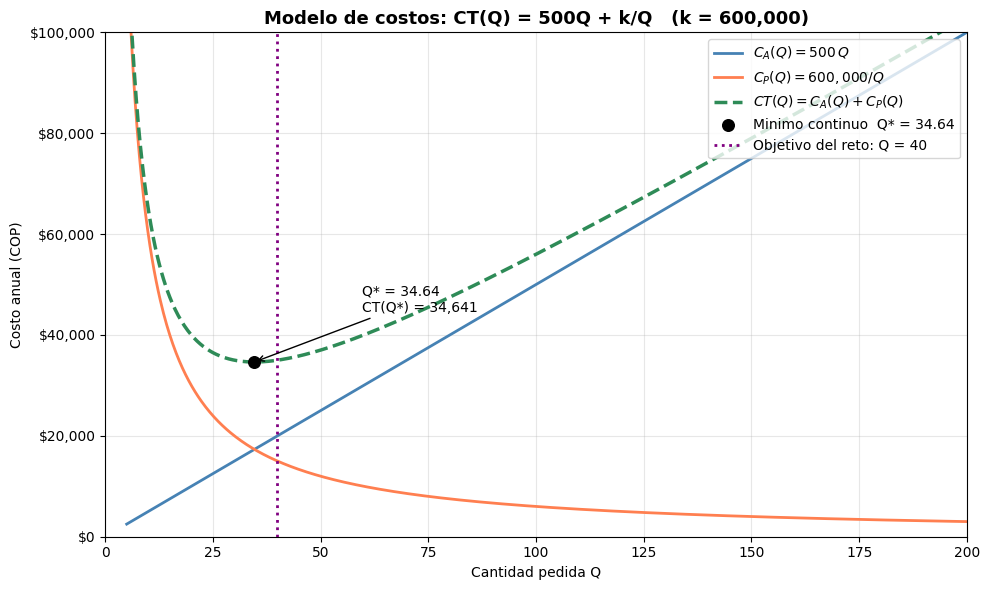

Con k = 600,000:
  Minimo CONTINUO en  Q* = 34.64
  CT(Q*) continuo     = 34,641.02

Compara este Q* (continuo) con el minimo DISCRETO de la tabla anterior
y con el objetivo Q = 40. ¿Que tendrias que hacer con k para mover Q* a 40?


In [4]:
# Celda 4: Grafica del modelo

def graficar_modelo(k, Q_min=5, Q_max=200, Q_objetivo=None):
    """Dibuja C_A(Q), C_P(Q) y CT(Q) para un k dado y marca el minimo continuo.
    Si se pasa Q_objetivo, se dibuja una linea vertical de referencia."""
    if Q_min <= 0:
        raise ValueError("Q_min debe ser positivo (Q > 0).")
    Q_vals = np.linspace(Q_min, Q_max, 800)

    # Minimo continuo del modelo (no de la tabla)
    Q_opt, CT_opt = minimo_teorico(k)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(Q_vals, costo_almacenamiento(Q_vals),
            color="steelblue", linewidth=2,
            label=r"$C_A(Q) = 500\,Q$")
    ax.plot(Q_vals, costo_pedido(Q_vals, k),
            color="coral", linewidth=2,
            label=rf"$C_P(Q) = {k:,}/Q$")
    ax.plot(Q_vals, costo_total(Q_vals, k),
            color="seagreen", linewidth=2.5, linestyle="--",
            label=r"$CT(Q) = C_A(Q) + C_P(Q)$")

    # Marcador y anotacion del minimo continuo
    ax.scatter([Q_opt], [CT_opt], color="black", s=70, zorder=5,
               label=f"Minimo continuo  Q* = {Q_opt:.2f}")
    ax.annotate(f"Q* = {Q_opt:.2f}\nCT(Q*) = {CT_opt:,.0f}",
                xy=(Q_opt, CT_opt),
                xytext=(Q_opt + 25, CT_opt + 10_000),
                fontsize=10,
                arrowprops=dict(arrowstyle="->", color="black"))

    if Q_objetivo is not None:
        ax.axvline(Q_objetivo, color="purple", linestyle=":", linewidth=2,
                   label=f"Objetivo del reto: Q = {Q_objetivo}")

    ax.set_title(f"Modelo de costos: CT(Q) = 500Q + k/Q   (k = {k:,})",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Cantidad pedida Q")
    ax.set_ylabel("Costo anual (COP)")
    ax.set_xlim(0, Q_max)
    ax.set_ylim(0, 100_000)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Grafica con el k de exploracion inicial
graficar_modelo(k_inicial, Q_objetivo=40)

Q_opt_ini, CT_opt_ini = minimo_teorico(k_inicial)
print(f"Con k = {k_inicial:,}:")
print(f"  Minimo CONTINUO en  Q* = {Q_opt_ini:.2f}")
print(f"  CT(Q*) continuo     = {CT_opt_ini:,.2f}")
print()
print("Compara este Q* (continuo) con el minimo DISCRETO de la tabla anterior")
print("y con el objetivo Q = 40. ¿Que tendrias que hacer con k para mover Q* a 40?")


In [5]:
# Celda 5: Explorador interactivo
# Mueve el slider de k y observa donde cae el minimo continuo Q*.
# Reto: encontrar el valor de k que hace que Q* sea exactamente 40.

def explorar(k):
    Q_objetivo = 40
    Q_opt, CT_opt = minimo_teorico(k)

    print(f"k actual         = {k:,}")
    print(f"Q* (continuo)    = {Q_opt:.3f}")
    print(f"CT(Q*) continuo  = {CT_opt:,.2f}")

    # Pista direccional, sin revelar el valor objetivo de k.
    if abs(Q_opt - Q_objetivo) < 0.5:
        print("¡Objetivo logrado! El minimo continuo cae practicamente en Q = 40.")
    elif Q_opt < Q_objetivo:
        print("El minimo continuo esta antes de Q = 40. Pista: aumenta k.")
    else:
        print("El minimo continuo esta despues de Q = 40. Pista: disminuye k.")

    graficar_modelo(k, Q_objetivo=Q_objetivo)

if WIDGETS_DISPONIBLES:
    # Paso de 10_000 para que el slider pase exactamente por valores como 800_000.
    interact(
        explorar,
        k=IntSlider(min=100_000, max=2_000_000, step=10_000,
                    value=600_000, description="k",
                    continuous_update=False),
    );
else:
    # Alternativa sin widgets: probamos algunos valores y el estudiante
    # puede llamar explorar(k) con sus propios numeros.
    print("Widgets no disponibles. Modo manual: prueba explorar(k) con tus valores.")
    for k_prueba in [400_000, 600_000, 1_000_000, 1_500_000]:
        print("\n" + "-" * 60)
        explorar(k_prueba)


interactive(children=(IntSlider(value=600000, continuous_update=False, description='k', max=2000000, min=10000…

### 6.4 Manos a la obra

1. **Encuentra el parametro objetivo.** <span style="color:blue">Usa el slider de $k$ hasta que el minimo de $CT(Q)$ quede en $Q=40$. Anota el valor aproximado de $k$ que encontraste.</span>

2. **Compara con algebra basica.** <span style="color:blue">Si $CT(Q)=500Q+\frac{k}{Q}$, explica con tus palabras por que cambiar $k$ mueve la posicion del minimo.</span>

3. **Pregunta para primer semestre.** <span style="color:blue">Con ayuda de la simulacion, responde: si quieres que la mejor decision sea pedir $40$ paquetes, ¿el valor de $k$ debe estar mas cerca de 200,000; 800,000; o 1,600,000? Justifica tu eleccion con lo que observas en la grafica.</span>

4. **Interpretacion administrativa.** <span style="color:blue">Explica brevemente que representa ese valor de $k$ en el contexto del supermercado y por que ayuda a tomar una decision de inventario mas eficiente.</span>